In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

train = pd.read_csv("../model_training/train.csv")

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  str    
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  str    
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  str    
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 2.7 MB


In [3]:
train.isnull().sum()

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

In [4]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [5]:
train[train['SQUARE_FT'] == 0].head(50)
#train[train['SQUARE_FT'] > 2000000].head(50)
train = train[train["SQUARE_FT"] < 200000]
train[train["SQUARE_FT"] > 200000].head(50)
train["SQUARE_FT"] = np.log1p(train["SQUARE_FT"])

<Axes: ylabel='SQUARE_FT'>

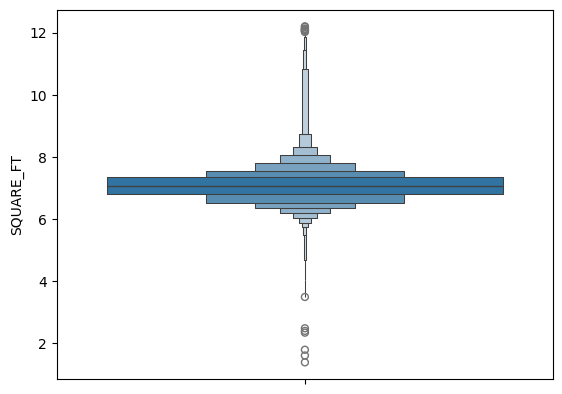

In [6]:
sns.boxenplot(train['SQUARE_FT'])

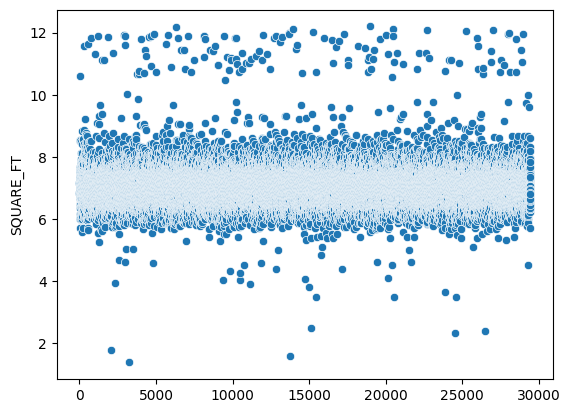

In [ ]:
plt.Figure(figsize=(15, 8))
sns.scatterplot(train["SQUARE_FT"])
plt.show()

<Axes: ylabel='BHK_NO.'>

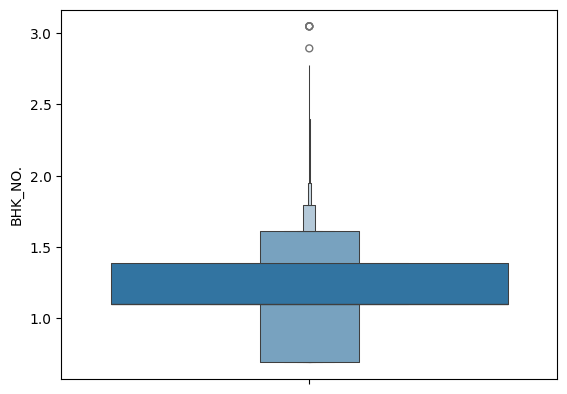

In [8]:
train["BHK_NO."] = np.log1p(train["BHK_NO."])
sns.boxenplot(train['BHK_NO.'])

In [9]:
train.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,1.098612,BHK,7.171070,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,1.098612,BHK,7.151485,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,1.098612,BHK,6.839647,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,1.098612,BHK,6.836175,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,1.098612,BHK,6.907765,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


array([[<Axes: title={'center': 'UNDER_CONSTRUCTION'}>,
        <Axes: title={'center': 'RERA'}>,
        <Axes: title={'center': 'BHK_NO.'}>],
       [<Axes: title={'center': 'SQUARE_FT'}>,
        <Axes: title={'center': 'READY_TO_MOVE'}>,
        <Axes: title={'center': 'RESALE'}>],
       [<Axes: title={'center': 'LONGITUDE'}>,
        <Axes: title={'center': 'LATITUDE'}>,
        <Axes: title={'center': 'TARGET(PRICE_IN_LACS)'}>]], dtype=object)

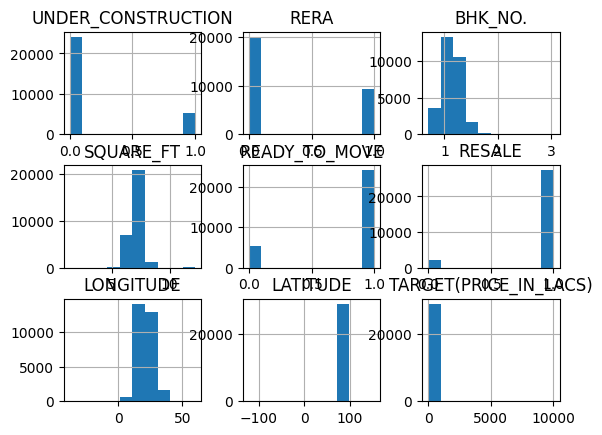

In [10]:
train.hist()

In [11]:
train.nunique()

POSTED_BY                    3
UNDER_CONSTRUCTION           2
RERA                         2
BHK_NO.                     16
BHK_OR_RK                    2
SQUARE_FT                19544
READY_TO_MOVE                2
RESALE                       2
ADDRESS                   6895
LONGITUDE                 4084
LATITUDE                  4075
TARGET(PRICE_IN_LACS)     1165
dtype: int64

In [12]:
train["POSTED_BY"] = train["POSTED_BY"].map({'Owner': 0, 'Dealer': 1, 'Builder': 2})
train["BHK_OR_RK"] = train["BHK_OR_RK"].map({"BHK": 0, "RK": 1})
train = train.drop(columns=["ADDRESS", "LONGITUDE", "LATITUDE"])

In [13]:
train.corr(method="spearman")

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,TARGET(PRICE_IN_LACS)
POSTED_BY,1.000000,0.253640,0.283669,0.093848,0.025151,0.099958,-0.253640,-0.290699,0.345550
UNDER_CONSTRUCTION,0.253640,1.000000,0.363422,-0.039842,0.020733,-0.107410,-1.000000,-0.346857,0.042153
RERA,0.283669,0.363422,1.000000,0.022491,0.006057,0.011506,-0.363422,-0.270054,0.150755
BHK_NO.,0.093848,-0.039842,0.022491,1.000000,-0.046894,0.817881,0.039842,0.014127,0.500436
BHK_OR_RK,0.025151,0.020733,0.006057,-0.046894,1.000000,-0.048559,-0.020733,-0.029414,-0.021106
SQUARE_FT,0.099958,-0.107410,0.011506,0.817881,-0.048559,1.000000,0.107410,0.085589,0.570150
READY_TO_MOVE,-0.253640,-1.000000,-0.363422,0.039842,-0.020733,0.107410,1.000000,0.346857,-0.042153
RESALE,-0.290699,-0.346857,-0.270054,0.014127,-0.029414,0.085589,0.346857,1.000000,-0.035516
TARGET(PRICE_IN_LACS),0.345550,0.042153,0.150755,0.500436,-0.021106,0.570150,-0.042153,-0.035516,1.000000


In [14]:
X = train[["POSTED_BY", "BHK_NO.", "SQUARE_FT", "RERA", "TARGET(PRICE_IN_LACS)"]]

In [15]:
X.head()

,POSTED_BY,BHK_NO.,SQUARE_FT,RERA,TARGET(PRICE_IN_LACS)
0,0,1.098612,7.171070,0,55.0
1,1,1.098612,7.151485,0,51.0
2,0,1.098612,6.839647,0,43.0
3,0,1.098612,6.836175,1,62.5
4,1,1.098612,6.907765,0,60.5


In [16]:
y = X["TARGET(PRICE_IN_LACS)"]
X = X.drop(columns="TARGET(PRICE_IN_LACS)")

In [17]:
y = y*100000

In [18]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
#X_scaled

In [19]:
#X = pd.DataFrame(X_scaled, columns=X.columns)

In [20]:
X

,POSTED_BY,BHK_NO.,SQUARE_FT,RERA
0,0,1.098612,7.171070,0
1,1,1.098612,7.151485,0
2,0,1.098612,6.839647,0
3,0,1.098612,6.836175,1
4,1,1.098612,6.907765,0
...,...,...,...,...
29446,0,1.386294,7.824446,0
29447,0,1.098612,6.646690,0
29448,1,1.098612,6.931122,0
29449,0,1.098612,6.833117,0


In [21]:
y

0        5500000.0
1        5100000.0
2        4300000.0
3        6250000.0
4        6050000.0
           ...    
29446    4500000.0
29447    1600000.0
29448    2710000.0
29449    6700000.0
29450    2780000.0
Name: TARGET(PRICE_IN_LACS), Length: 29434, dtype: float64

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(n_estimators=1000, max_depth=10)
forest.fit(X_train, y_train)
forest.score(X_train, y_train)

0.9616621504155713

In [24]:
prediction = forest.predict(X_test)
print(r2_score(y_test, prediction))
print(mean_absolute_error(y_test, prediction))
print(np.sqrt(mean_squared_error(y_test, prediction)))

0.8483112823645603
6256061.905299162
22718815.650117416


In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(forest, X, y, cv=5, scoring="r2")
print("CV R2:", scores.mean())


CV R2: 0.8999453664648055


In [26]:
print(scores)

[0.8976688  0.93837005 0.91603544 0.8946867  0.85296584]


In [27]:
mape = np.mean(np.abs((y_test - prediction) / y_test)) * 100
print(mape)

88.01731732321244


In [28]:
print("Min price:", y_test.min())

Min price: 25000.0
